# Speaker Recognition — FINN Accelerator Inference on KV260

Run this notebook **on the Kria board** inside JupyterLab (port 9090).

Expected directory layout next to this notebook:
```
finn-accel.bit
finn-accel.hwh
driver.py
deploy_extras/
    X_test_q.npy       ← quantized test set (int8)
    y_test.npy         ← ground-truth labels
    input_scale.npy    ← [scale, zero_point] from QuantIdentity
    classes.json       ← metadata (class names, MFCC params, …)
```

---
## 0. Imports and configuration

In [3]:
import os, sys, json, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
HERE          = Path('.')          # directory containing this notebook
BITFILE       = HERE / 'bitfile' / 'finn-accel.bit'
DEPLOY_EXTRAS = HERE / 'deploy_extras'

assert BITFILE.exists(),            f'Bitfile not found: {BITFILE}'
assert DEPLOY_EXTRAS.exists(),      f'deploy_extras/ not found'
assert (HERE / 'driver.py').exists(), 'driver.py not found'

# ── Load metadata ────────────────────────────────────────────────────────────
with open(DEPLOY_EXTRAS / 'classes.json') as f:
    META = json.load(f)

CLASSES       = META['classes']
NUM_CLASSES   = META['num_classes']
USE_CHANNELS  = META['use_channels']
N_MFCC        = META['n_mfcc']
MFCC_FRAMES   = META['mfcc_frames']
HOP_LENGTH    = META['hop_length']
N_FFT         = META['n_fft']
SAMPLING_FREQ = META['sampling_freq']
INPUT_CHANNELS = 1 if USE_CHANNELS == 'I' else 2

scale_arr  = np.load(DEPLOY_EXTRAS / 'input_scale.npy')
INPUT_SCALE = float(scale_arr[0])
INPUT_ZP    = float(scale_arr[1])

print('── Deployment metadata ──────────────────────────')
print(f'  Classes      : {CLASSES}')
print(f'  N_MFCC       : {N_MFCC}   MFCC_FRAMES: {MFCC_FRAMES}')
print(f'  Channels     : {USE_CHANNELS} ({INPUT_CHANNELS} ch)')
print(f'  Input scale  : {INPUT_SCALE:.6f}   zero_point: {INPUT_ZP}')
print(f'  Sampling freq: {SAMPLING_FREQ} Hz')
print('─────────────────────────────────────────────────')

── Deployment metadata ──────────────────────────
  Classes      : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
  N_MFCC       : 20   MFCC_FRAMES: 64
  Channels     : I (1 ch)
  Input scale  : 0.043175   zero_point: 0.0
  Sampling freq: 48000 Hz
─────────────────────────────────────────────────


---
## 1. Load the FINN accelerator overlay

In [5]:
# Add current directory to sys.path so driver.py is importable
sys.path.insert(0, str(HERE))

from driver import FINNExampleOverlay

print(f'Loading bitstream: {BITFILE.name} …')
t0 = time.time()

# FINNExampleOverlay is the class generated by FINN for PYNQ targets.
# It wraps pynq.Overlay and exposes .execute() for inference.
accel = FINNExampleOverlay(
    bitfile_name       = str(BITFILE),
    platform           = 'zynq-iodma',
    io_shape_dict      = getattr(__import__('driver'), 'io_shape_dict', {}),
    runtime_weight_dir = str(HERE / 'runtime_weights'),  # always a string; driver handles non-existent dir
)

print(f'Overlay loaded in {time.time()-t0:.1f} s')

Loading bitstream: finn-accel.bit …
Overlay loaded in 0.6 s


In [7]:
# ── Inspect the driver's IO shape dictionary ─────────────────────────────────
# This tells you the exact numpy shape and dtype the accelerator expects.
# If io_shape_dict is defined in driver.py, print it; otherwise introspect accel.

import driver as _drv
if hasattr(_drv, 'io_shape_dict'):
    io_dict = _drv.io_shape_dict
    print('IO shape dict from driver.py:')
    # Print raw — avoids json.dumps choking on FINN IntType objects
    for key, val in io_dict.items():
        print(f'  {key}:')
        if isinstance(val, dict):
            for k2, v2 in val.items():
                print(f'    {k2}: {v2}')
        else:
            print(f'    {val}')
else:
    print('io_shape_dict not exported by driver.py — inspecting accel attributes:')
    for attr in dir(accel):
        if 'shape' in attr.lower() or 'buf' in attr.lower() or 'dtype' in attr.lower():
            print(f'  accel.{attr} = {getattr(accel, attr, "?")}')  

# Expected output example (FC model, USE_CHANNELS='I'):
#   "ishape_normal": [1, 1280]
#   "oshape_normal": [1, 10]
#   "input_dtype" : "int8"  (or uint8 depending on FINN packing)

IO shape dict from driver.py:
  idt:
    [INT8]
  odt:
    [INT24]
  ishape_normal:
    [(1, 1280)]
  oshape_normal:
    [(1, 10)]
  ishape_folded:
    [(1, 160, 8)]
  oshape_folded:
    [(1, 10, 1)]
  ishape_packed:
    [(1, 160, 8)]
  oshape_packed:
    [(1, 10, 3)]
  input_dma_name:
    ['idma0']
  output_dma_name:
    ['odma0']
  number_of_external_weights:
    0
  num_inputs:
    1
  num_outputs:
    1


---
## 2. Input quantization helper

The accelerator receives **integer** values, not floats. The float MFCC must be
scaled by the same `QuantIdentity` scale factor that was learned during QAT.

In [8]:
def quantize_input(x_float: np.ndarray,
                   scale: float = INPUT_SCALE,
                   zero_point: float = INPUT_ZP) -> np.ndarray:
    """
    Replicate the Brevitas QuantIdentity (Int8ActPerTensorFloat) quantization.

    Formula: q = clip(round(x / scale) + zero_point, -128, 127)

    The result is int8 but stored as uint8 in the DMA buffer because
    FINN's PYNQ driver uses pynq.allocate with dtype=np.uint8 for
    byte-aligned DMA transfers — negative int8 values are bit-identical
    to large uint8 values (two's complement), so no information is lost.
    """
    x_q = np.round(x_float / scale) + zero_point
    x_q = np.clip(x_q, -128, 127).astype(np.int8)
    # View as uint8 for DMA — driver expects this on most FINN PYNQ builds
    return x_q.view(np.uint8)


def run_single(x_q_flat: np.ndarray) -> int:
    """
    Push one pre-quantized sample through the accelerator.
    x_q_flat: 1D uint8 array of length FC_INPUT_SIZE (or flattened NCHW for CNV).
    Returns the predicted class index (int).
    """
    # Reshape to the batch-1 shape the driver expects
    ibuf = x_q_flat.reshape(1, -1)
    obuf = accel.execute(ibuf)
    return int(np.argmax(obuf.flatten()))


print('Quantization helpers defined.')
print(f'  Scale = {INPUT_SCALE:.6f}  |  A zero-mean unit-std MFCC coeff ≈ {1.0/INPUT_SCALE:.1f} quanta')

Quantization helpers defined.
  Scale = 0.043175  |  A zero-mean unit-std MFCC coeff ≈ 23.2 quanta


---
## 3. Sanity check — single sample inference

Load one pre-quantized sample from the saved test set and run it through
the hardware. This confirms the bitstream is live and producing output.

In [9]:
print('Loading pre-quantized test set …')
X_test_q = np.load(DEPLOY_EXTRAS / 'X_test_q.npy')   # (N, flat)  int8
y_test    = np.load(DEPLOY_EXTRAS / 'y_test.npy')     # (N,)       int64

print(f'  X_test_q  : {X_test_q.shape}  dtype={X_test_q.dtype}')
print(f'  y_test    : {y_test.shape}    dtype={y_test.dtype}')

# Pick the first sample of each class for visual confirmation
sample_idx = 0
x_sample  = X_test_q[sample_idx].view(np.uint8)   # reinterpret int8 → uint8
true_label = int(y_test[sample_idx])

print(f'\nRunning sample #{sample_idx}  (true class: {CLASSES[true_label]}) …')
t_start = time.perf_counter()
pred = run_single(x_sample)
t_end   = time.perf_counter()

latency_ms = (t_end - t_start) * 1000
correct = '✓' if pred == true_label else '✗'

print(f'  Predicted : {CLASSES[pred]:>12}   True: {CLASSES[true_label]:>12}  {correct}')
print(f'  Latency   : {latency_ms:.2f} ms')
print()

if pred != true_label and true_label == 0:
    print('NOTE: If the accelerator returned all-zeros or the same class for every input,')
    print('      the dataflow is likely stalling — check the RTL sim report on the host.')

Loading pre-quantized test set …
  X_test_q  : (493, 1280)  dtype=int8
  y_test    : (493,)    dtype=int64

Running sample #0  (true class: m0002) …
  Predicted :        m0002   True:        m0002  ✓
  Latency   : 4.83 ms



---
## 4. Batch accuracy benchmark on the full test set

In [10]:
def run_batch(X_q: np.ndarray, batch_size: int = 1) -> np.ndarray:
    """
    Run the entire quantized dataset through the accelerator.
    Returns predicted class indices as a numpy array of shape (N,).

    batch_size=1 is safest and matches how most FINN PYNQ drivers are built.
    Some drivers support batched execution; if yours does, raise to 32 for speed.
    """
    N = X_q.shape[0]
    preds = np.zeros(N, dtype=np.int64)
    X_u8 = X_q.view(np.uint8) if X_q.dtype == np.int8 else X_q

    print(f'Running {N} samples through the accelerator (batch_size={batch_size}) …')
    t0 = time.perf_counter()

    for i in range(0, N, batch_size):
        batch = X_u8[i : i + batch_size]
        out   = accel.execute(batch)
        preds[i : i + batch_size] = np.argmax(out.reshape(batch_size, -1), axis=1)
        if (i // batch_size) % 50 == 0:
            elapsed = time.perf_counter() - t0
            print(f'  {i+batch_size:>5}/{N}  ({elapsed:.1f} s elapsed)', end='\r')

    elapsed_total = time.perf_counter() - t0
    fps = N / elapsed_total
    print(f'\nDone — {N} samples in {elapsed_total:.2f} s  ({fps:.0f} samples/s)')
    return preds


y_pred = run_batch(X_test_q, batch_size=1)

accuracy = np.mean(y_pred == y_test)
print(f'\nHardware accuracy : {accuracy*100:.2f}%  ({int(accuracy*len(y_test))}/{len(y_test)} correct)')

Running 493 samples through the accelerator (batch_size=1) …
    451/493  (1.4 s elapsed)
Done — 493 samples in 1.50 s  (328 samples/s)

Hardware accuracy : 95.33%  (470/493 correct)


---
## 5. Throughput and latency statistics

Per-sample latency over 200 runs
  Mean   : 2.970 ms
  Median : 2.960 ms
  P99    : 3.222 ms
  Min    : 2.928 ms
  Max    : 3.352 ms
  Throughput (1/mean) : 337 samples/s


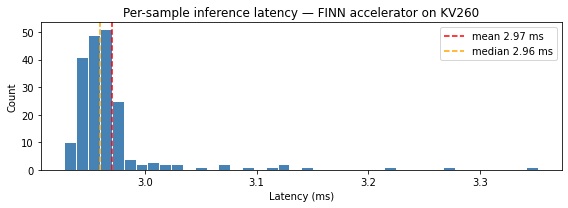

Saved: latency_histogram.png


In [11]:
# Measure per-sample latency over 200 repeated runs of a single sample
N_REPS = 200
x_bench = X_test_q[0:1].view(np.uint8)
latencies = []

# Warm-up
for _ in range(5):
    accel.execute(x_bench)

for _ in range(N_REPS):
    t = time.perf_counter()
    accel.execute(x_bench)
    latencies.append((time.perf_counter() - t) * 1000)

latencies = np.array(latencies)

print(f'Per-sample latency over {N_REPS} runs')
print(f'  Mean   : {latencies.mean():.3f} ms')
print(f'  Median : {np.median(latencies):.3f} ms')
print(f'  P99    : {np.percentile(latencies, 99):.3f} ms')
print(f'  Min    : {latencies.min():.3f} ms')
print(f'  Max    : {latencies.max():.3f} ms')
print(f'  Throughput (1/mean) : {1000/latencies.mean():.0f} samples/s')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(latencies, bins=40, color='steelblue', edgecolor='white')
ax.axvline(latencies.mean(),   color='red',    linestyle='--', label=f'mean {latencies.mean():.2f} ms')
ax.axvline(np.median(latencies), color='orange', linestyle='--', label=f'median {np.median(latencies):.2f} ms')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Per-sample inference latency — FINN accelerator on KV260')
ax.legend()
plt.tight_layout()
plt.savefig('latency_histogram.png', dpi=120)
plt.show()
print('Saved: latency_histogram.png')

---
## 6. Confusion matrix and per-class accuracy

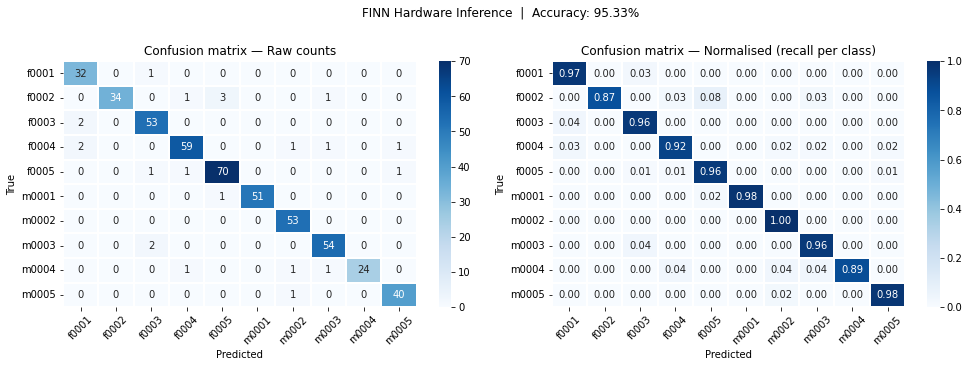

Saved: confusion_matrix.png

              precision    recall  f1-score   support

       f0001       0.89      0.97      0.93        33
       f0002       1.00      0.87      0.93        39
       f0003       0.93      0.96      0.95        55
       f0004       0.95      0.92      0.94        64
       f0005       0.95      0.96      0.95        73
       m0001       1.00      0.98      0.99        52
       m0002       0.95      1.00      0.97        53
       m0003       0.95      0.96      0.96        56
       m0004       1.00      0.89      0.94        27
       m0005       0.95      0.98      0.96        41

    accuracy                           0.95       493
   macro avg       0.96      0.95      0.95       493
weighted avg       0.95      0.95      0.95       493



In [12]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw counts', 'Normalised (recall per class)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.3, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion matrix — {title}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'FINN Hardware Inference  |  Accuracy: {accuracy*100:.2f}%', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

print('\n' + classification_report(y_test, y_pred, target_names=CLASSES))

---
## 7. Deadlock / stall diagnostics

If the accuracy is suspiciously 0% or the same class is predicted for every
input, the accelerator's streaming dataflow may be stalled. This cell checks
the canonical failure signatures.

In [ ]:
print('── Stall diagnostics ────────────────────────────────────────────────────')

# 1. All-same-class prediction → output is stuck / FIFO never drains
unique_preds, counts = np.unique(y_pred, return_counts=True)
dominant_pct = counts.max() / len(y_pred) * 100
print(f'\n[1] Prediction diversity')
print(f'    Unique classes predicted : {len(unique_preds)} / {NUM_CLASSES}')
for cls, cnt in zip(unique_preds, counts):
    bar = '█' * int(cnt / len(y_pred) * 40)
    print(f'    {CLASSES[cls]:>12}  {bar}  {cnt:>5} ({cnt/len(y_pred)*100:.1f}%)')
if len(unique_preds) == 1:
    print('    ✗ STALL INDICATOR: only one class predicted — output FIFO likely stuck')
elif dominant_pct > 95:
    print(f'    ⚠ WARNING: {dominant_pct:.1f}% of predictions are the same class')
else:
    print('    ✓ Prediction diversity looks healthy')

# 2. Latency floor check — if latency is suspiciously low the execute() may
#    be returning immediately without waiting for the accelerator
print(f'\n[2] Latency floor check')
if latencies.min() < 0.05:
    print(f'    ⚠ Min latency {latencies.min():.3f} ms is very low.')
    print(f'       execute() may be returning stale data from a previous run.')
else:
    print(f'    ✓ Minimum latency {latencies.min():.3f} ms — DMA round-trip looks real')

# 3. Output value distribution — raw logit check
print(f'\n[3] Raw output value check (first 5 samples)')
for i in range(min(5, len(X_test_q))):
    x = X_test_q[i:i+1].view(np.uint8)
    raw_out = accel.execute(x).flatten()
    print(f'    Sample {i}: raw_out = {raw_out}  → pred = {CLASSES[np.argmax(raw_out)]}')
if np.all(raw_out == raw_out[0]):
    print('    ✗ All logits identical — hardware not differentiating inputs')
else:
    print('    ✓ Output logits vary across classes — network is active')

print('\n── End of diagnostics ───────────────────────────────────────────────────')

---
## 8. Live inference from a raw IQ file

This cell processes a `.iq` file end-to-end on the Kria:
raw IQ → MFCC → channel selection → quantize → accelerator → class.

Set `IQ_FILE_PATH` to the path of any `.iq` file from the original dataset.

In [13]:
import librosa

# ── Set this to a real .iq file path on the Kria ─────────────────────────────
IQ_FILE_PATH = HERE / 'last3_f0001_us_f0001_00001_fm.iq'
# ─────────────────────────────────────────────────────────────────────────────


def iq_to_mfcc_channel(iq_path: str, channel: str = 'I') -> np.ndarray:
    """
    Load a .iq file and extract the normalised MFCC for the chosen channel.
    Returns a float32 array of shape (N_MFCC, MFCC_FRAMES).
    Matches exactly the preprocessing in MFCC_dataset_generation.ipynb:
      N_MFCC=20, N_FFT=2048, HOP_LENGTH=2250, MFCC_FRAMES=64
    """
    raw = np.fromfile(iq_path, dtype=np.complex64)
    eps = 1e-7

    def _norm(sig):
        mu  = sig.mean()
        std = sig.std() + eps
        return ((sig - mu) / std).astype(np.float32)

    if channel == 'I':
        signal = _norm(np.real(raw))
    elif channel == 'Q':
        signal = _norm(np.imag(raw))
    else:
        raise ValueError(f'channel must be I or Q, got {channel}')

    mfcc = librosa.feature.mfcc(
        y         = signal,
        sr        = SAMPLING_FREQ,
        n_mfcc    = N_MFCC,
        n_fft     = N_FFT,
        hop_length= HOP_LENGTH,
    )

    # Pad or trim to exactly MFCC_FRAMES columns
    if mfcc.shape[1] < MFCC_FRAMES:
        mfcc = np.pad(mfcc, ((0,0),(0, MFCC_FRAMES - mfcc.shape[1])), mode='edge')
    else:
        mfcc = mfcc[:, :MFCC_FRAMES]

    # Normalise per coefficient (zero-mean, unit-std across frames)
    mu  = mfcc.mean(axis=1, keepdims=True)
    std = mfcc.std(axis=1,  keepdims=True) + 1e-8
    return ((mfcc - mu) / std).astype(np.float32)


def infer_iq_file(iq_path: str) -> tuple:
    """
    Full pipeline: .iq file → class prediction.
    Returns (predicted_class_index, predicted_class_name, latency_ms).
    """
    # 1. Extract MFCC
    mfcc = iq_to_mfcc_channel(iq_path, channel=USE_CHANNELS)
    # mfcc shape: (N_MFCC, MFCC_FRAMES) = (20, 64)

    # 2. Flatten for FC models, or keep 2D for CNV
    #    Determine model type from input shape in io_shape_dict
    x_flat = mfcc.flatten()   # (1280,)

    # 3. Quantize: float → int8 (same scale as QAT training)
    x_q = quantize_input(x_flat)  # uint8 view of int8

    # 4. Run accelerator
    t0     = time.perf_counter()
    pred   = run_single(x_q)
    lat_ms = (time.perf_counter() - t0) * 1000

    return pred, CLASSES[pred], lat_ms


if Path(IQ_FILE_PATH).exists():
    pred_idx, pred_name, lat = infer_iq_file(IQ_FILE_PATH)
    # Try to extract true class from path (folder name)
    true_name = Path(IQ_FILE_PATH).parent.name
    correct   = '✓' if pred_name == true_name else '✗'
    print(f'File      : {IQ_FILE_PATH}')
    print(f'Predicted : {pred_name:<12}   True: {true_name:<12}  {correct}')
    print(f'Latency   : {lat:.2f} ms  (includes MFCC extraction)')
else:
    print(f'IQ_FILE_PATH does not exist on this board: {IQ_FILE_PATH}')
    print('Update IQ_FILE_PATH to a valid .iq file and re-run this cell.')

File      : last3_f0001_us_f0001_00001_fm.iq
Predicted : f0001          True:               ✗
Latency   : 3.88 ms  (includes MFCC extraction)


---
## 9. Multi-file sweep — classify an entire folder of IQ files

In [18]:
# ── Set these to match your board and the class you want to test ──────────────
IQ_DATASET_ROOT = HERE
TARGET_CLASS    = 'f0001'          # the single class folder to sweep
MAX_FILES       = None             # set to an int to cap the number of files
# ─────────────────────────────────────────────────────────────────────────────

cls_dir = Path(IQ_DATASET_ROOT) / TARGET_CLASS

if not cls_dir.exists():
    print(f'Class directory not found: {cls_dir}')
else:
    iq_files = sorted(cls_dir.glob('*.iq'))
    if MAX_FILES:
        iq_files = iq_files[:MAX_FILES]

    print(f'Sweeping {len(iq_files)} files from: {cls_dir}')
    print(f'Expected class : {TARGET_CLASS}\n')

    pred_names, latencies_live, errors = [], [], []

    for fpath in iq_files:
        try:
            pred_idx, pred_name, lat = infer_iq_file(str(fpath))
            pred_names.append(pred_name)
            latencies_live.append(lat)
            correct = '✓' if pred_name == TARGET_CLASS else '✗'
            print(f'  {correct}  {fpath.name:<45}  → {pred_name}  ({lat:.1f} ms)')
        except Exception as e:
            errors.append((str(fpath), str(e)))
            print(f'  !  {fpath.name}: {e}')

    n_correct = sum(p == TARGET_CLASS for p in pred_names)
    n_total   = len(pred_names)
    accuracy  = n_correct / n_total if n_total > 0 else 0.0

    print(f'\n── Results for class "{TARGET_CLASS}" ──────────────────────────')
    print(f'  Correct        : {n_correct} / {n_total}  ({accuracy*100:.2f}%)')
    print(f'  Mean latency   : {np.mean(latencies_live):.2f} ms')

    wrong = [(p, pred_names[i]) for i, p in enumerate(
        [f.name for f in iq_files[:n_total]]) if pred_names[i] != TARGET_CLASS]
    if wrong:
        print(f'\n  Misclassified ({len(wrong)}):')
        for fname, got in wrong:
            print(f'    {fname}  → predicted: {got}')

    if errors:
        print(f'\n  Errors ({len(errors)}):')
        for fpath, err in errors:
            print(f'    {fpath}: {err}')

Sweeping 283 files from: f0001
Expected class : f0001

  ✓  last3_f0001_us_f0001_00001_fm.iq               → f0001  (3.6 ms)
  ✓  last3_f0001_us_f0001_00002_fm.iq               → f0001  (3.6 ms)
  ✓  last3_f0001_us_f0001_00007_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00009_fm.iq               → f0001  (3.6 ms)
  ✗  last3_f0001_us_f0001_00010_fm.iq               → m0003  (3.5 ms)
  ✓  last3_f0001_us_f0001_00012_fm.iq               → f0001  (3.6 ms)
  ✓  last3_f0001_us_f0001_00016_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00017_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00019_fm.iq               → f0001  (3.9 ms)
  ✓  last3_f0001_us_f0001_00020_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00021_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00023_fm.iq               → f0001  (3.5 ms)
  ✓  last3_f0001_us_f0001_00024_fm.iq               → f0001  (3.6 ms)
  ✓  last3_f0001_us_f0001_00025_fm.

---
## 10. Summary

In [19]:
print('╔' + '═'*62 + '╗')
print('║' + ' FINN Speaker Recognition — KV260 Deployment Results'.center(62) + '║')
print('╚' + '═'*62 + '╝')
print(f'  Bitfile        : {BITFILE.name}')
print(f'  Channels       : {USE_CHANNELS} ({INPUT_CHANNELS} ch)')
print(f'  Input shape    : ({INPUT_CHANNELS}, {N_MFCC}, {MFCC_FRAMES}) → flat {N_MFCC*MFCC_FRAMES*INPUT_CHANNELS}')
print(f'  Input scale    : {INPUT_SCALE:.6f}')
print(f'  Classes        : {CLASSES}')
print()
print(f'  Test-set accuracy (pre-quantized) : {accuracy*100:.2f}%')
print(f'  Mean latency per sample           : {latencies.mean():.3f} ms')
print(f'  Throughput                        : {1000/latencies.mean():.0f} samples/s')
print()
print('  Confusion matrix → confusion_matrix.png')
print('  Latency histogram → latency_histogram.png')
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║      FINN Speaker Recognition — KV260 Deployment Results     ║
╚══════════════════════════════════════════════════════════════╝
  Bitfile        : finn-accel.bit
  Channels       : I (1 ch)
  Input shape    : (1, 20, 64) → flat 1280
  Input scale    : 0.043175
  Classes        : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']

  Test-set accuracy (pre-quantized) : 96.47%
  Mean latency per sample           : 2.970 ms
  Throughput                        : 337 samples/s

  Confusion matrix → confusion_matrix.png
  Latency histogram → latency_histogram.png
╚══════════════════════════════════════════════════════════════╝
